## Description of Gold Price:
The price of gold is a dynamic and globally influential economic indicator that reflects the value of gold per unit of weight. Gold is a precious metal with a long history of being used as a store of value, a medium of exchange, and a symbol of wealth. It is traded on various commodities exchanges worldwide, and its price is influenced by a myriad of factors, including economic conditions, geopolitical events, inflation, interest rates, and currency movements.  

Investors often turn to gold as a safe-haven asset during times of economic uncertainty, as its value tends to be inversely correlated with the strength of traditional financial markets. Additionally, gold is widely used in jewelry and has industrial applications, further impacting its demand and, consequently, its price.  

## Machine Learning Solutions for Gold Price Prediction:
Machine learning (ML) can be leveraged to analyze historical and real-time data, helping to predict and understand the complex patterns that influence gold prices. Here are ways in which machine learning can contribute to solving challenges related to predicting gold prices:  

```
Time Series Analysis:
    Machine learning algorithms, particularly those designed for time series analysis, can analyze historical gold price data to identify trends, seasonal patterns, and cyclic behaviors. This information can be valuable for predicting future price movements.

Sentiment Analysis:
    ML models can process vast amounts of textual data from news articles, social media, and financial reports to gauge market sentiment. Sentiment analysis can provide insights into how positive or negative news and events might impact investor confidence and influence gold prices.

Macro-Economic Indicators:
    ML algorithms can assimilate and analyze macroeconomic indicators such as inflation rates, interest rates, and currency values. By understanding the relationships between these factors and gold prices, machine learning models can make predictions based on changes in economic conditions.

Geopolitical Event Impact Assessment:
    Geopolitical events often have a significant impact on gold prices. Machine learning can assess historical data to understand how events such as political instability, trade tensions, or global crises have affected gold prices, enabling predictions for similar events in the future.

Integration of Alternative Data Sources:
    ML models can incorporate alternative data sources, such as satellite imagery to assess mining activities, or shipping data to gauge demand for gold. Integrating diverse datasets can enhance the accuracy of predictions by providing a more comprehensive view of the factors influencing gold prices.

Portfolio Optimization:
    Machine learning can assist investors in optimizing their portfolios by recommending strategies based on predicted gold price movements. This includes dynamically adjusting asset allocations and hedging strategies to manage risk.
```

While machine learning holds promise in predicting gold prices, it's important to note that financial markets are inherently unpredictable, and models may not always accurately forecast future movements. Additionally, market dynamics can change rapidly, requiring continuous model refinement and adaptation. Collaborative efforts between financial experts, data scientists, and regulatory bodies are essential to ensure responsible and informed use of machine learning in predicting gold prices.

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style("darkgrid")

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
os.getcwd()

/kaggle/input/datasets/altruistdelhite04/gold-price-data/gld_price_data.csv


'/kaggle/working'

## Loading Dataset

In [3]:
gold_df = pd.read_csv("../input/datasets/altruistdelhite04/gold-price-data/gld_price_data.csv")
gold_df.shape

(2290, 6)

In [4]:
df = gold_df.copy()
df.head(10).style.background_gradient(cmap='copper')

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180000,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285000,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167000,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053000,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590000,1.557099
5,1/9/2008,1409.130005,86.550003,75.250000,15.520000,1.466405
6,1/10/2008,1420.329956,88.250000,74.019997,16.061001,1.480100
7,1/11/2008,1401.020020,88.580002,73.089996,16.077000,1.479006
8,1/14/2008,1416.250000,89.540001,74.250000,16.280001,1.486900
9,1/15/2008,1380.949951,87.989998,72.779999,15.834000,1.480210


## Basic Information on Dataset

In [5]:
df.shape

(2290, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


| Variable Name	| Description |
| ------------- | ----------- |
| Date | Date in MM/dd/yyyy format |
| SPX | The Standard and Poor's 500 index (S&P 500), a stock market index tracking 500 major US companies |
| GLD | Gold price |
| USO | United States Oil Fund ® LP (USO), an exchange-traded security traded on the NYSE Arca.
| SLV | Silver price |
| EUR/USD | Euro to US dollar exchange ratio |

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.describe().T.style.background_gradient(cmap="summer")

,count,mean,std,min,25%,50%,75%,max
SPX,2290.000000,1654.315776,519.111540,676.530029,1239.874969,1551.434998,2073.010070,2872.870117
GLD,2290.000000,122.732875,23.283346,70.000000,109.725000,120.580002,132.840004,184.589996
USO,2290.000000,31.842221,19.523517,7.960000,14.380000,33.869999,37.827501,117.480003
SLV,2290.000000,20.084997,7.092566,8.850000,15.570000,17.268500,22.882500,47.259998
EUR/USD,2290.000000,1.283653,0.131547,1.039047,1.171313,1.303297,1.369971,1.598798


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

Date       2290
SPX        2277
GLD        1930
USO        1514
SLV        1331
EUR/USD    2066
dtype: int64

## EDA and Visualizations

Univariate

array([[<Axes: title={'center': 'SPX'}>, <Axes: title={'center': 'GLD'}>,
        <Axes: title={'center': 'USO'}>, <Axes: title={'center': 'SLV'}>,
        <Axes: title={'center': 'EUR/USD'}>]], dtype=object)

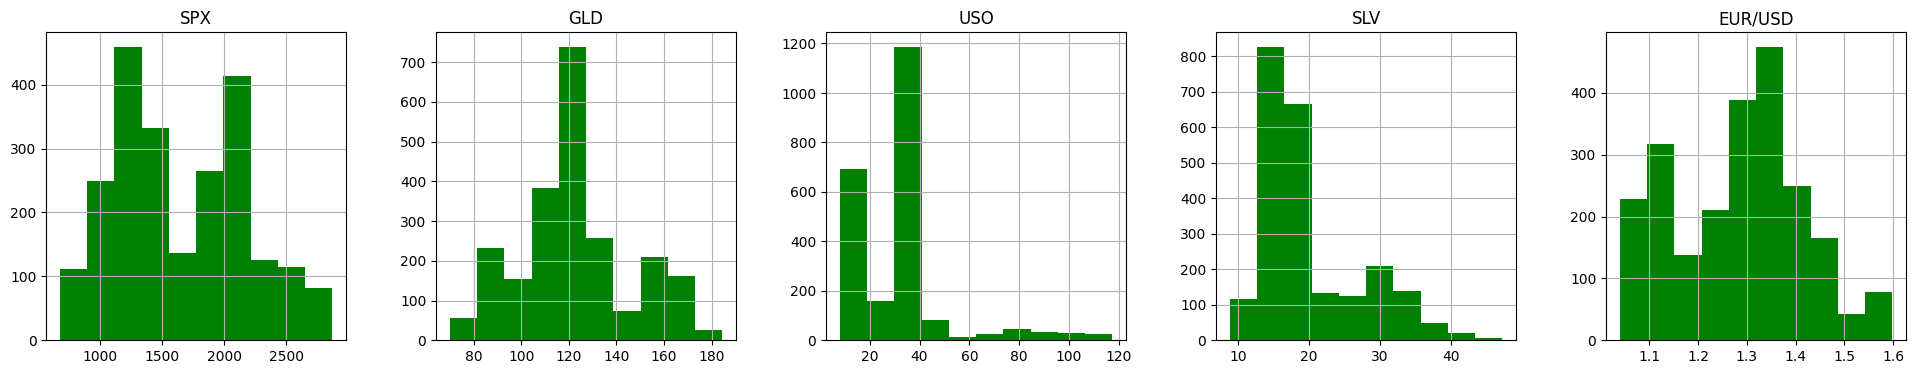

In [11]:
df.hist(figsize=(24, 4), layout=(1, 5), color='green')

In [12]:
df.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

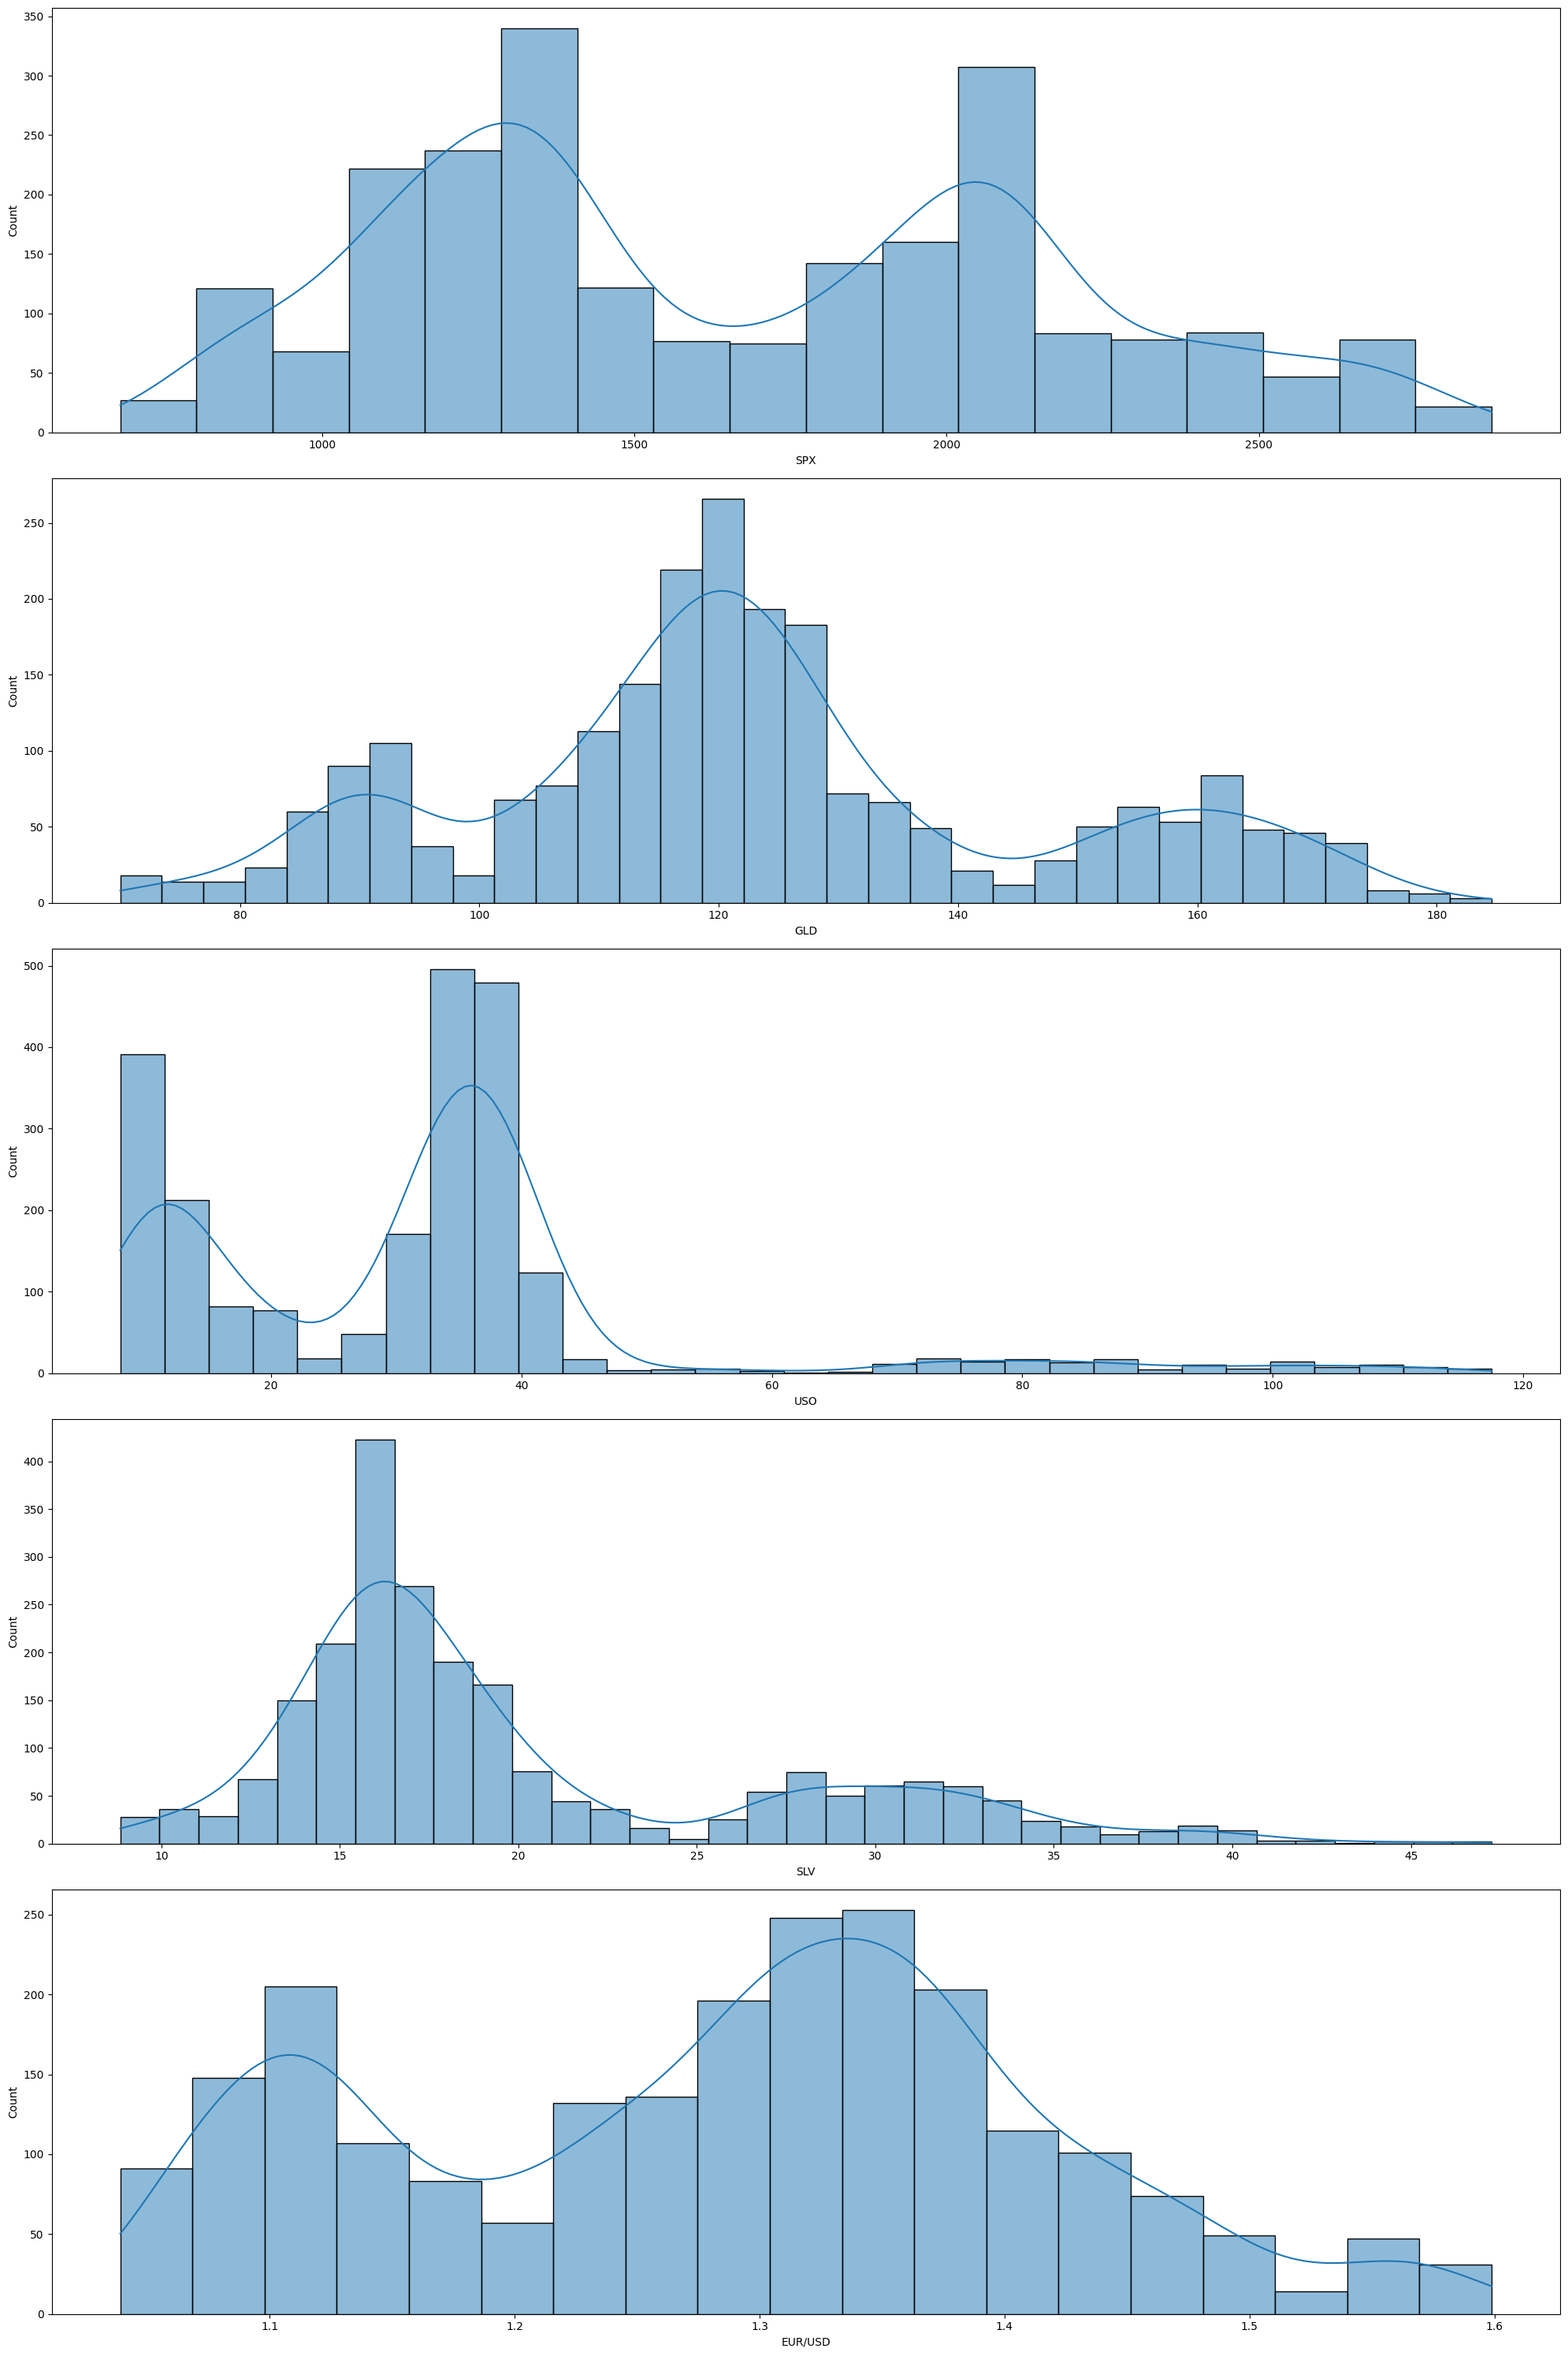

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(20, 30))
axes = axes.flatten()

# sns.histplot(ax=axes[0], x='SPX', data=df, kde=True)
# sns.histplot(ax=axes[1], x='GLD', data=df, kde=True)
# sns.histplot(ax=axes[2], x='USO', data=df, kde=True)
# sns.histplot(ax=axes[3], x='SLV', data=df, kde=True)
# sns.histplot(ax=axes[4], x='EUR/USD', data=df, kde=True)
for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
    sns.histplot(ax=axes[i], x=col, data=df, kde=True)

plt.tight_layout()
plt.show()

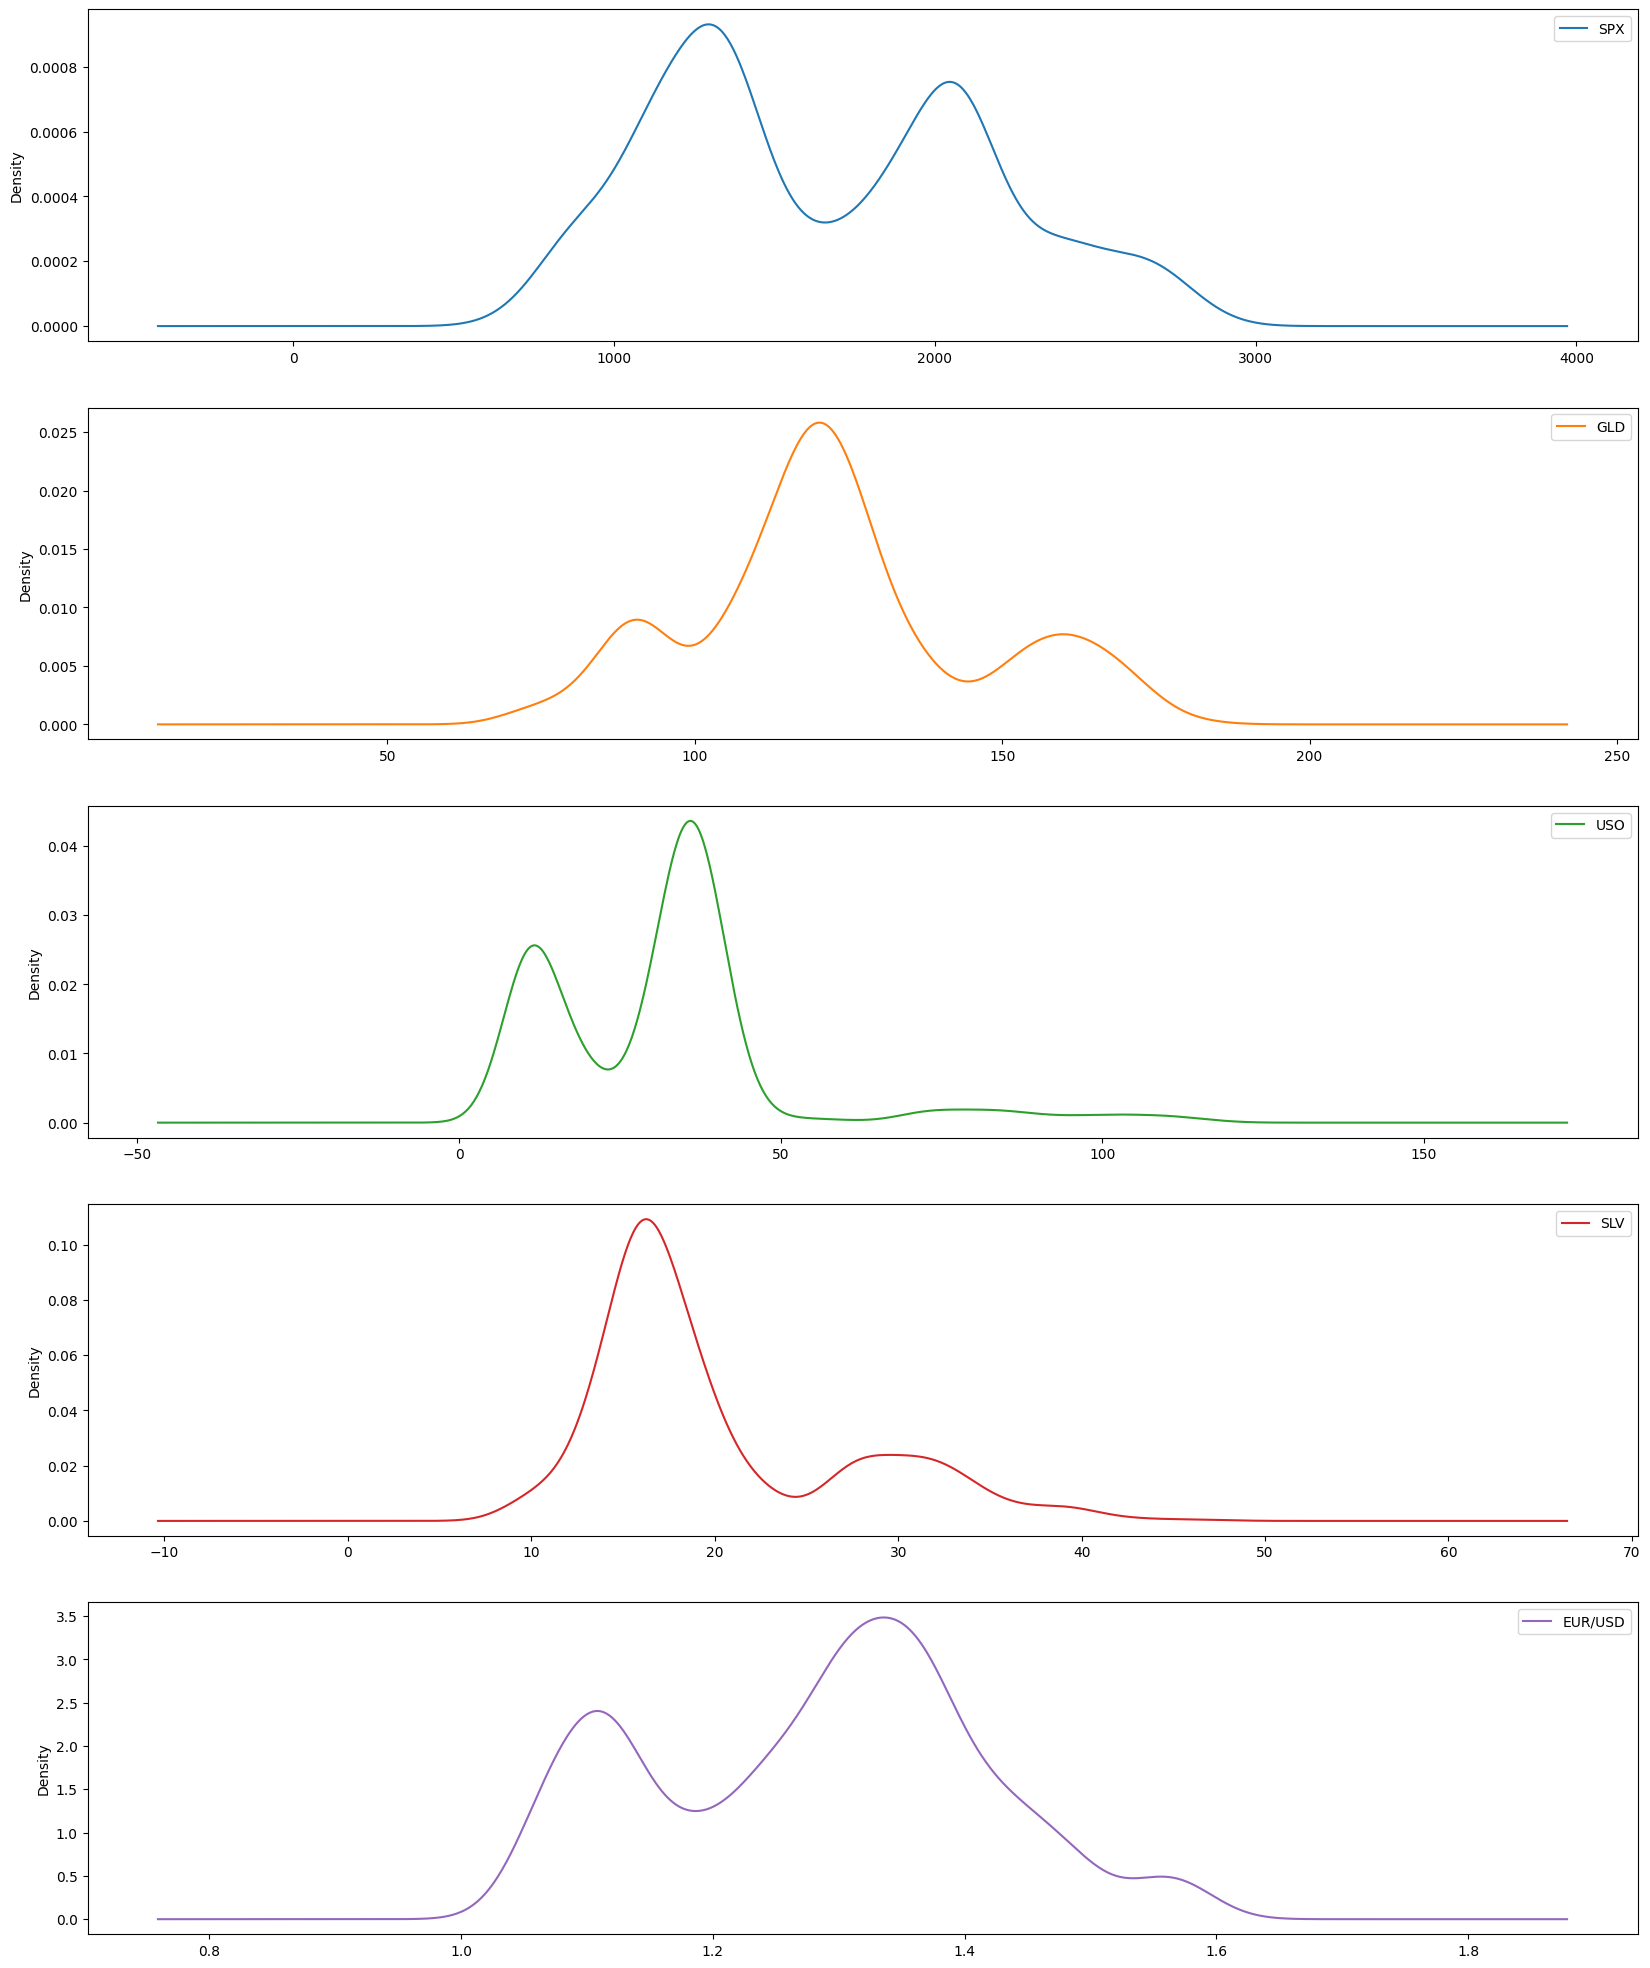

In [14]:
df.plot(kind="kde", subplots=True, layout=(5, 1), figsize=(20, 25),sharex=False, sharey=False);

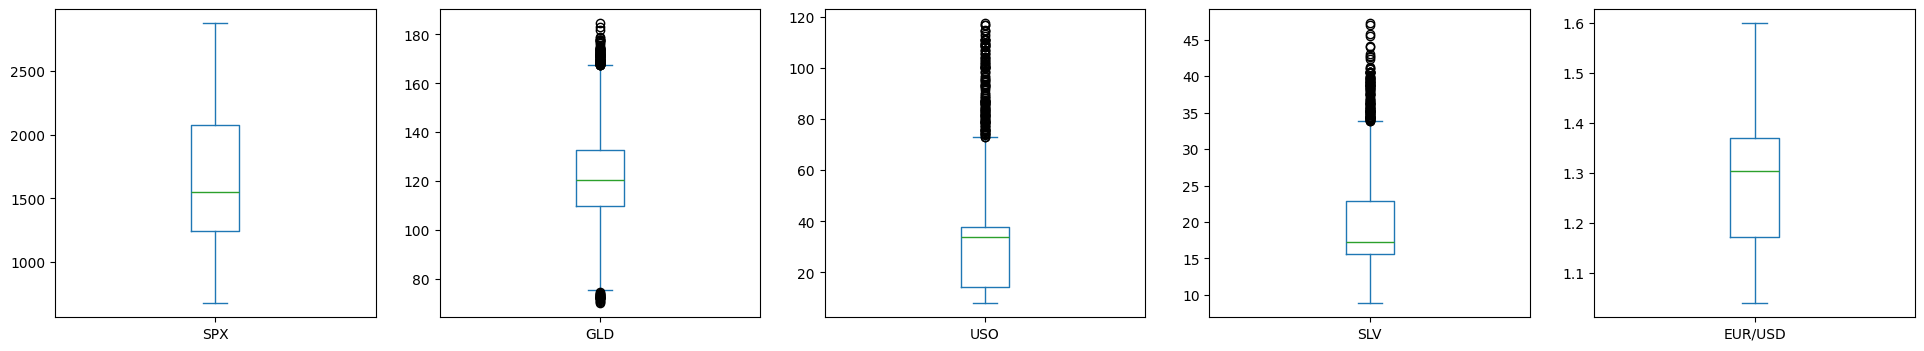

In [15]:
df.plot(kind="box", subplots=True, layout=(1, 5), figsize=(24, 4), sharex=False, sharey=False);

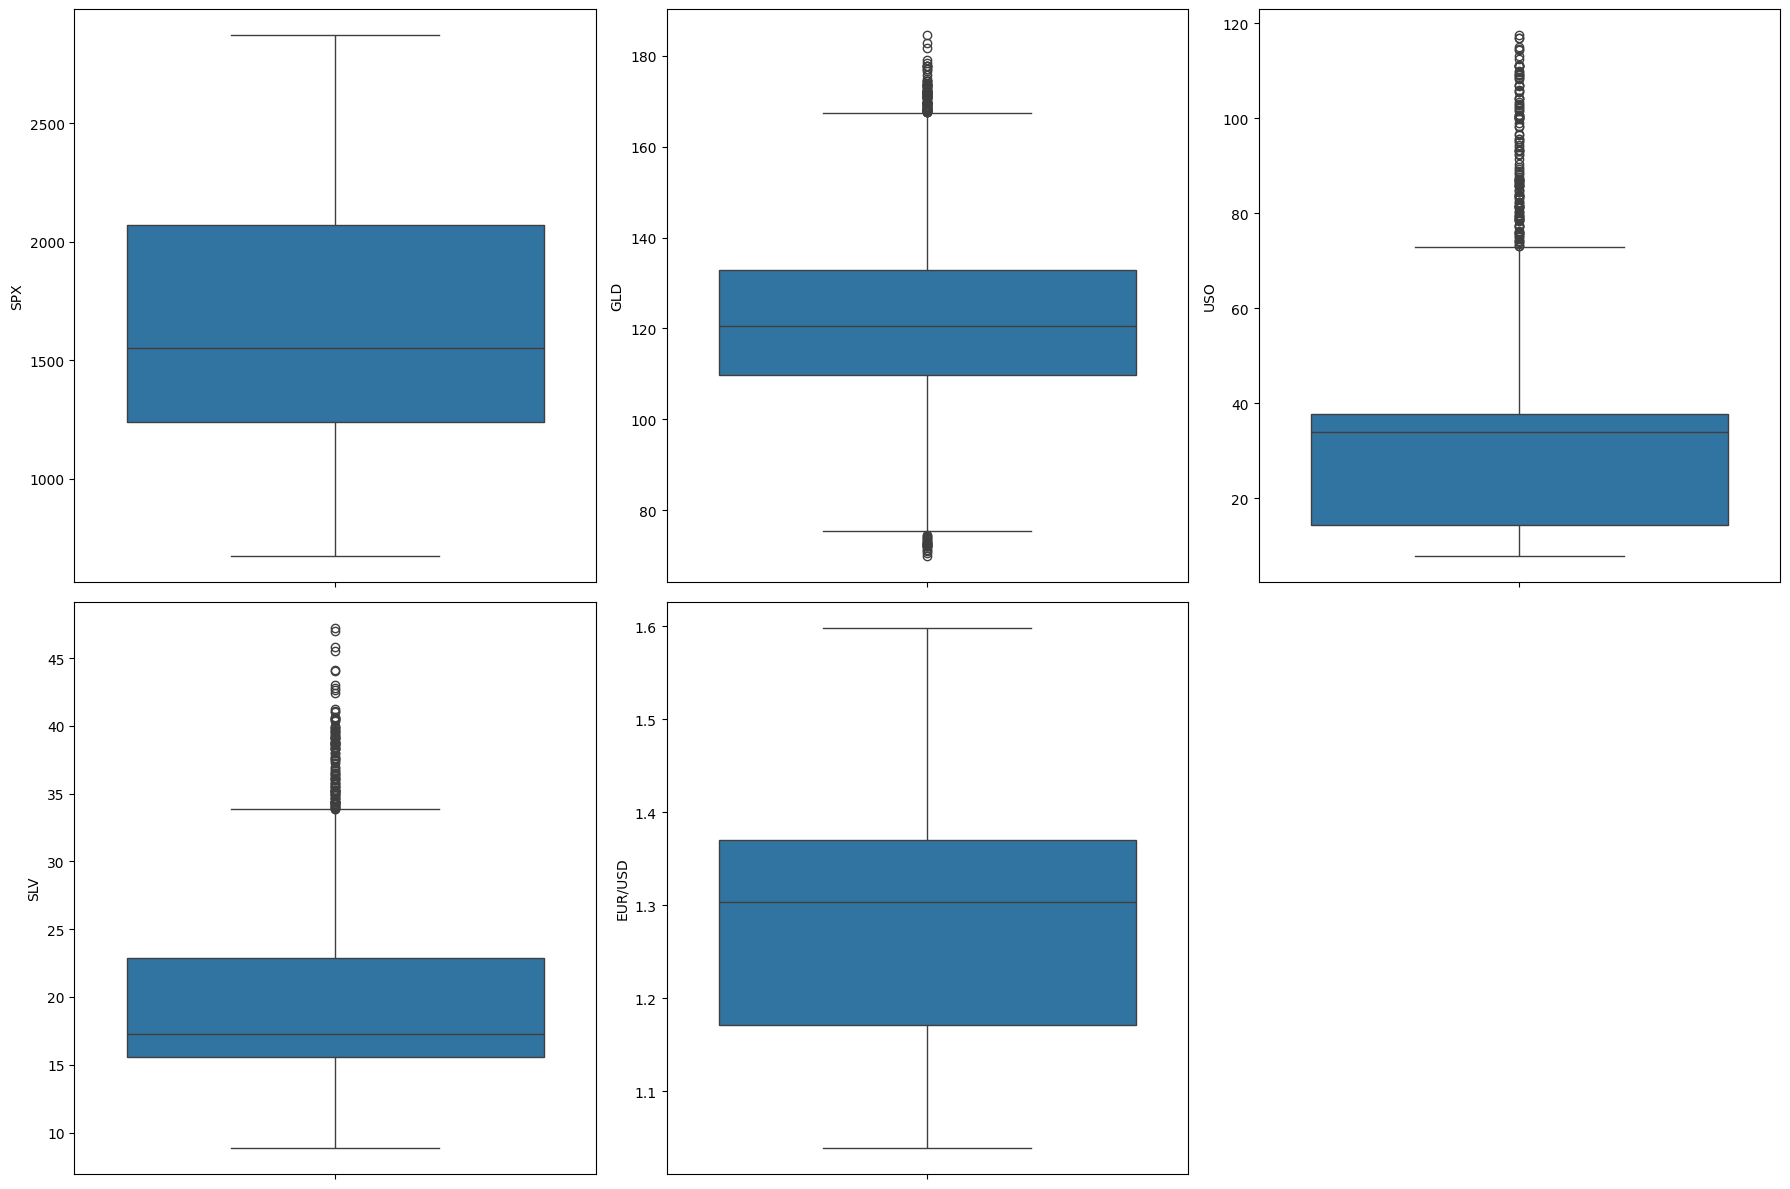

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
    sns.boxplot(ax=axes[i], y=col, data=df)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

Multivariate

In [17]:
df.corr(numeric_only=True).T.style.background_gradient(cmap="magma")

,SPX,GLD,USO,SLV,EUR/USD
SPX,1.000000,0.049345,-0.591573,-0.274055,-0.672017
GLD,0.049345,1.000000,-0.186360,0.866632,-0.024375
USO,-0.591573,-0.186360,1.000000,0.167547,0.829317
SLV,-0.274055,0.866632,0.167547,1.000000,0.321631
EUR/USD,-0.672017,-0.024375,0.829317,0.321631,1.000000


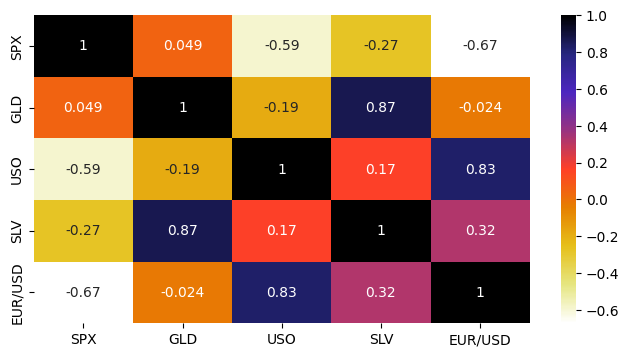

In [18]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=plt.cm.CMRmap_r);

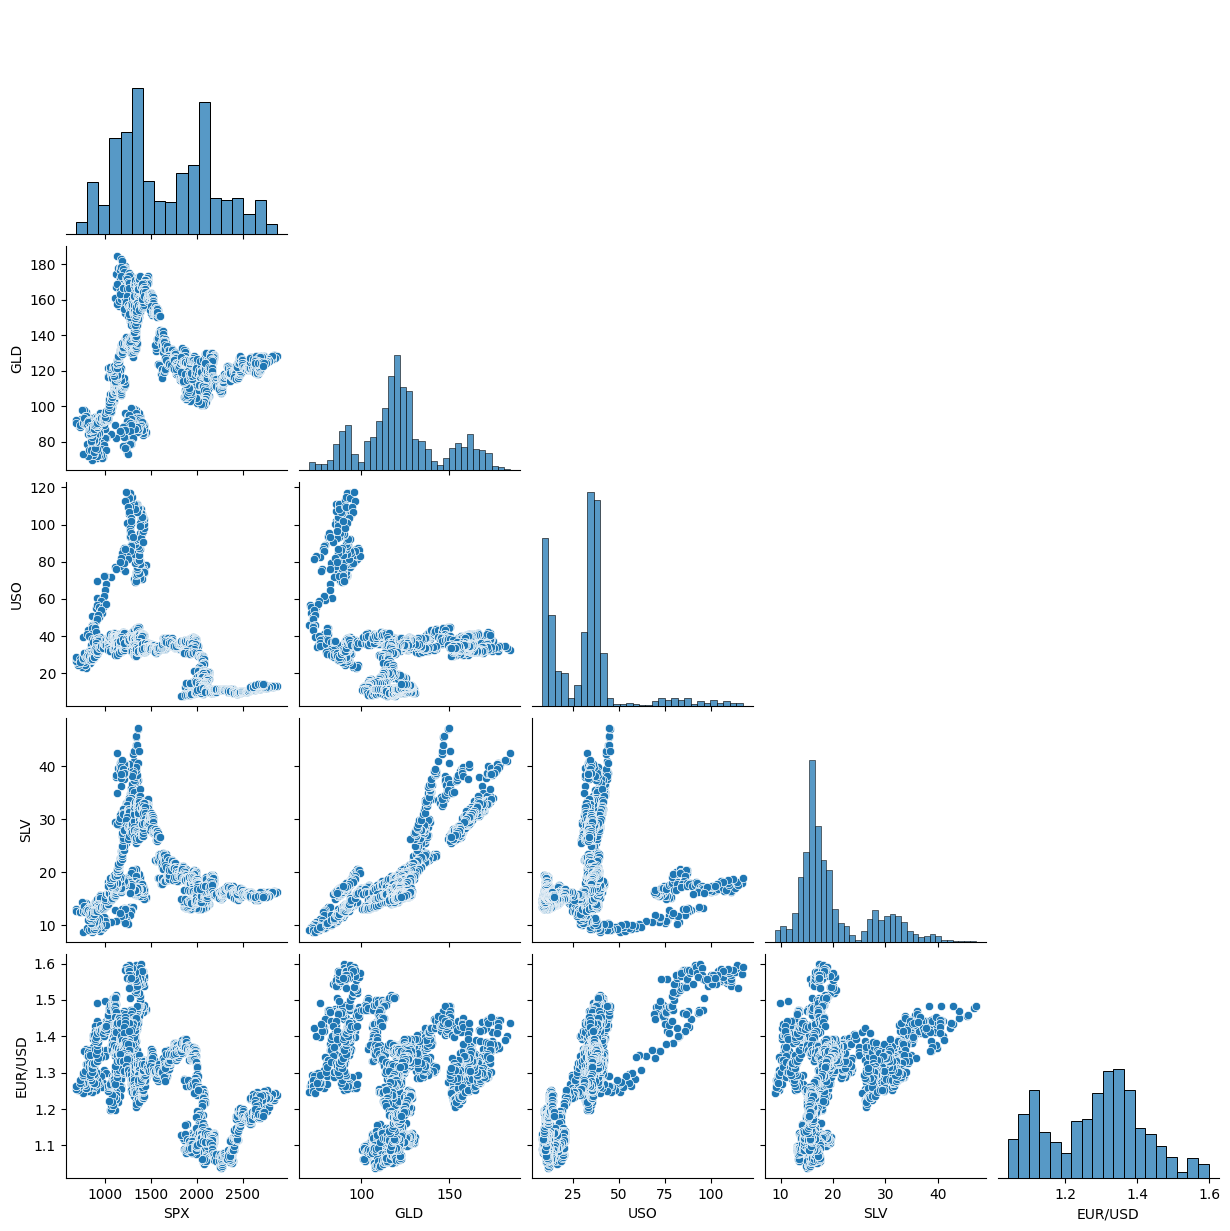

In [19]:
sns.pairplot(data=df, diag_kind='hist', corner=True)

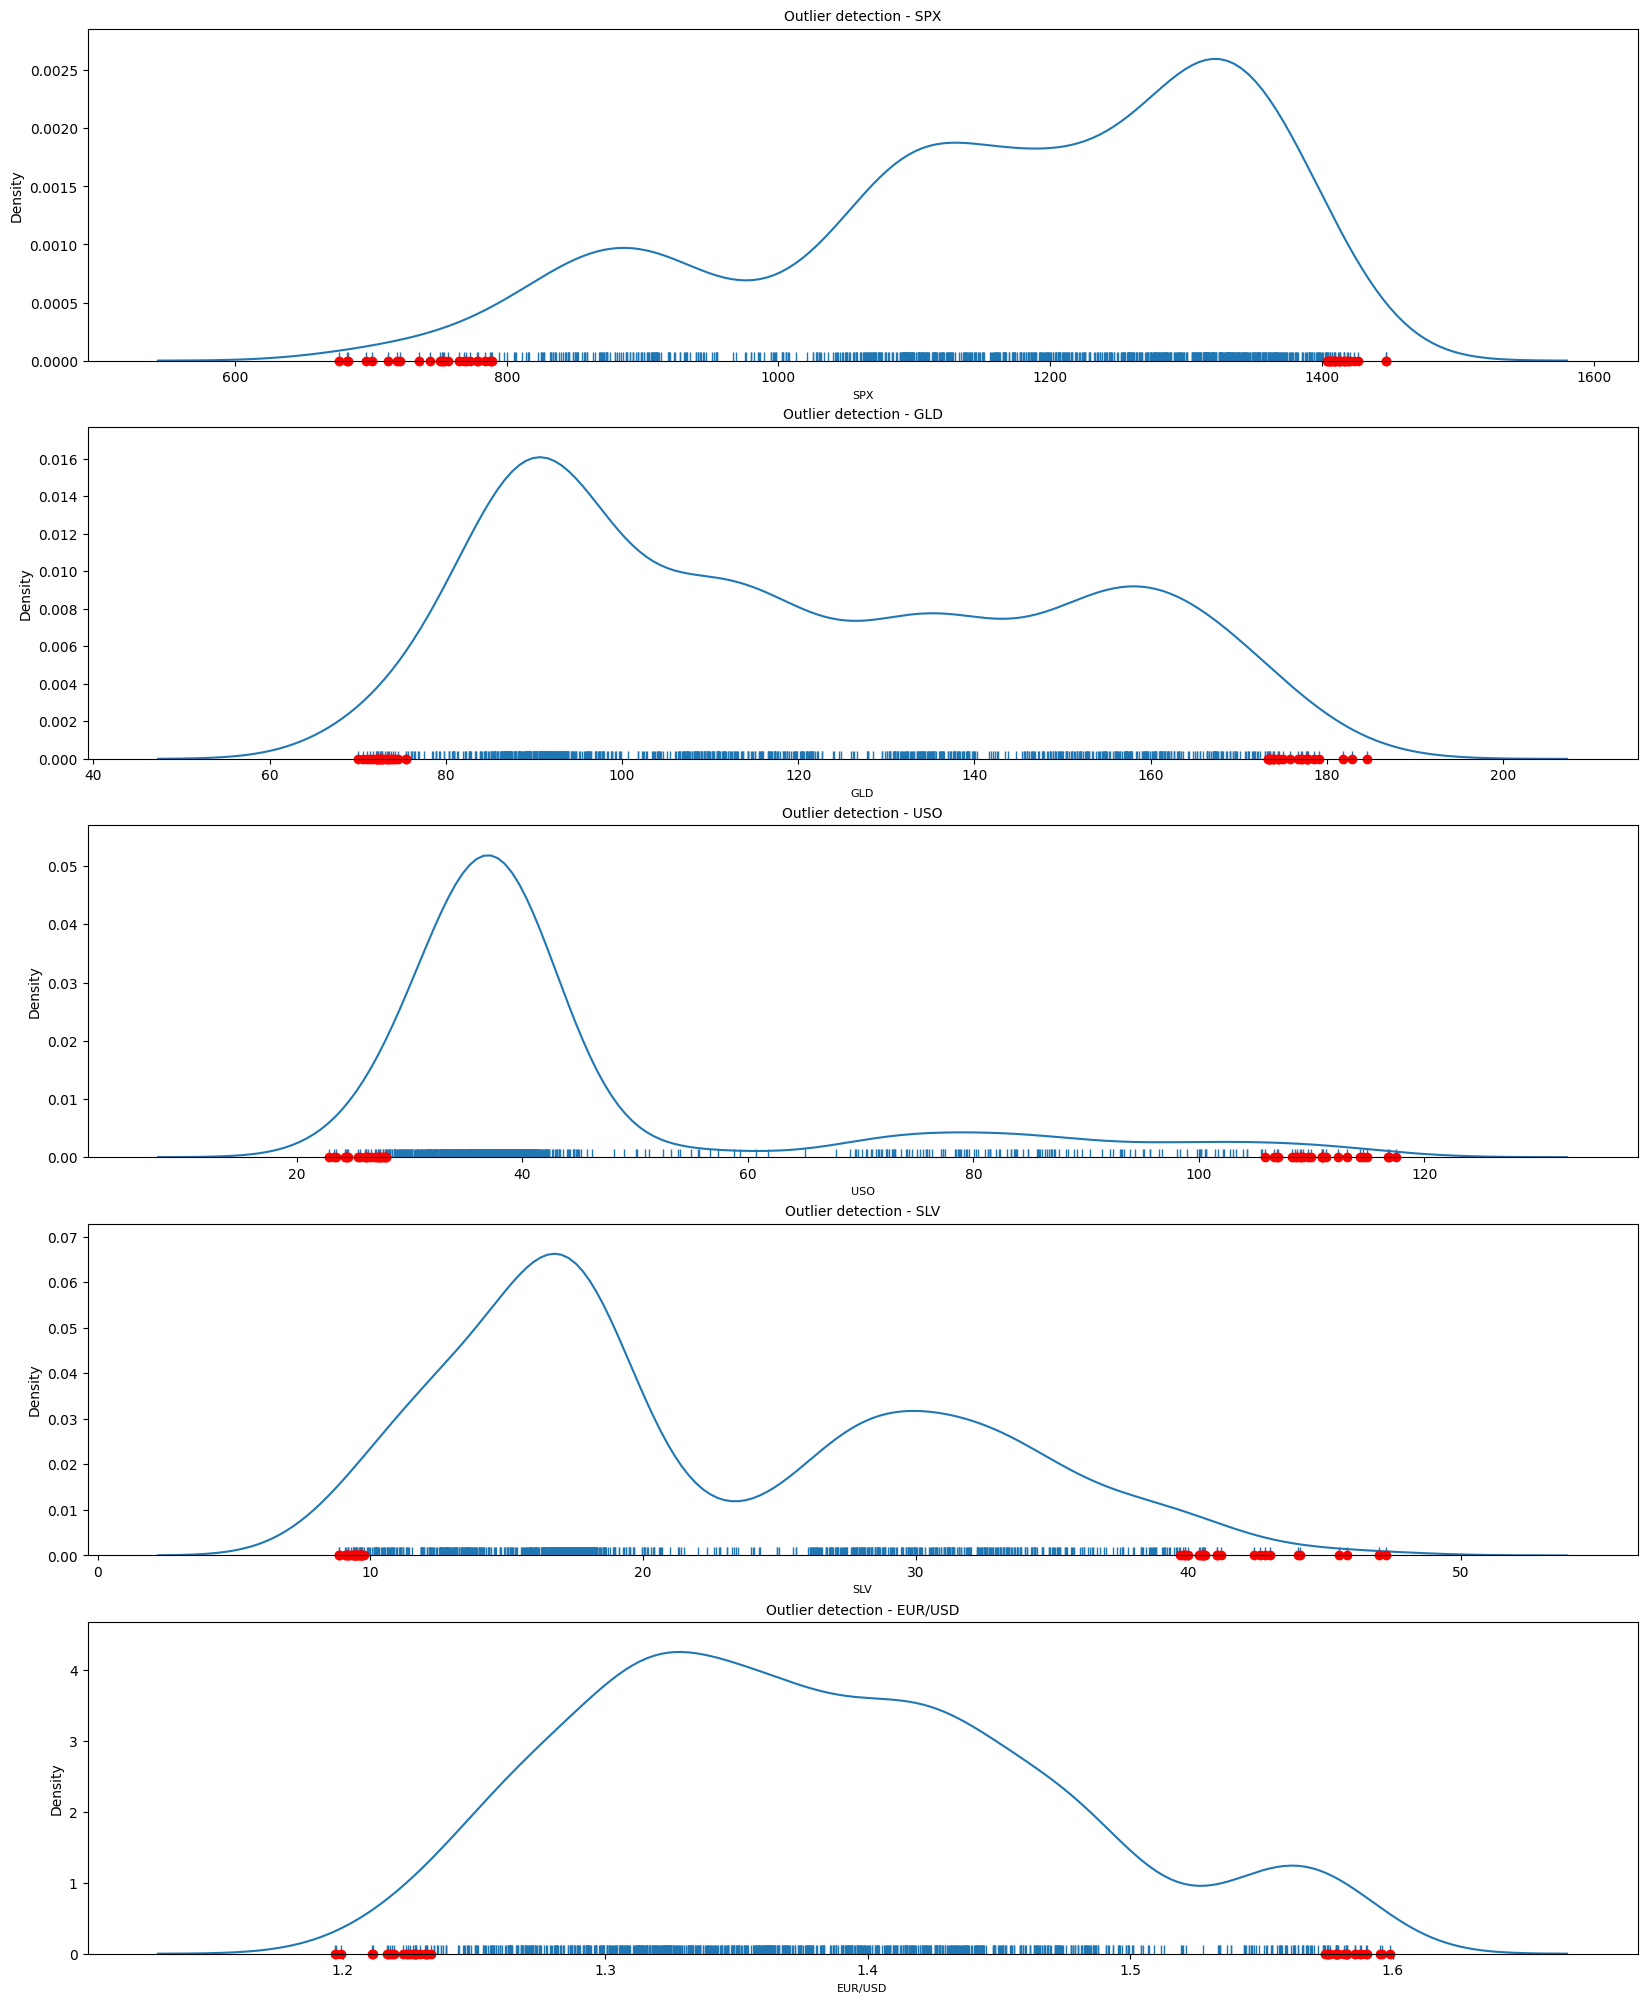

In [20]:
def percentile_based_outlier(data, threshold=95):
    diff = (100 - threshold) / 2
    minval, maxval = np.percentile(data, [diff, 100 - diff])
    return (data < minval) | (data > maxval)

col_names = df.select_dtypes(include=['int', 'float']).columns.tolist()

fig, ax = plt.subplots(len(col_names), figsize=(20,25))

for i, col_val in enumerate(col_names):
    x = df[col_val][:1000]
    sns.distplot(x, ax=ax[i], rug=True, hist=False)
    outliers = x[percentile_based_outlier(x)]
    ax[i].plot(outliers, np.zeros_like(outliers), 'ro', clip_on=False)

    ax[i].set_title('Outlier detection - {}'.format(col_val), fontsize=10)
    ax[i].set_xlabel(col_val, fontsize=8)

plt.show()

## Data Preprocessing

In [21]:
df.head(10).style.background_gradient(cmap="copper")

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180000,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285000,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167000,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053000,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590000,1.557099
5,1/9/2008,1409.130005,86.550003,75.250000,15.520000,1.466405
6,1/10/2008,1420.329956,88.250000,74.019997,16.061001,1.480100
7,1/11/2008,1401.020020,88.580002,73.089996,16.077000,1.479006
8,1/14/2008,1416.250000,89.540001,74.250000,16.280001,1.486900
9,1/15/2008,1380.949951,87.989998,72.779999,15.834000,1.480210


In [22]:
df["Date"] = pd.to_datetime(df.Date)

In [23]:
df.head(10).style.background_gradient(cmap="copper")

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02 00:00:00,1447.160034,84.860001,78.470001,15.180000,1.471692
1,2008-01-03 00:00:00,1447.160034,85.570000,78.370003,15.285000,1.474491
2,2008-01-04 00:00:00,1411.630005,85.129997,77.309998,15.167000,1.475492
3,2008-01-07 00:00:00,1416.180054,84.769997,75.500000,15.053000,1.468299
4,2008-01-08 00:00:00,1390.189941,86.779999,76.059998,15.590000,1.557099
5,2008-01-09 00:00:00,1409.130005,86.550003,75.250000,15.520000,1.466405
6,2008-01-10 00:00:00,1420.329956,88.250000,74.019997,16.061001,1.480100
7,2008-01-11 00:00:00,1401.020020,88.580002,73.089996,16.077000,1.479006
8,2008-01-14 00:00:00,1416.250000,89.540001,74.250000,16.280001,1.486900
9,2008-01-15 00:00:00,1380.949951,87.989998,72.779999,15.834000,1.480210


In [24]:
y = df["GLD"]
X = df.drop(columns=["Date", "GLD"], axis=1)

In [25]:
X.shape, y.shape

((2290, 4), (2290,))

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1832, 4), (458, 4), (1832,), (458,))

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.feature_selection import SelectKBest

fs = SelectKBest(k=3)
X_train_scaled = fs.fit_transform(X_train, y_train)
X_test_scaled = fs.transform(X_test)

This does two things:

fit()  
    - Computes a score for each feature using X_train and y_train.  
    - Ranks the features.  
transform()  
    - Keeps only the top 3 ranked features.  
    - Removes the remaining feature.  

In [29]:
X_train.shape, X_train_scaled.shape, X_test.shape, X_test_scaled.shape

((1832, 4), (1832, 3), (458, 4), (458, 3))

In [30]:
fs.get_support() # It removed 4th Feature

array([ True,  True,  True, False])

## Model Building and Evaluation

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import HuberRegressor
from sklearn.svm import SVR
from xgboost.sklearn import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

In [32]:
lr = LinearRegression().fit(X_train_scaled, y_train)
y_lr = lr.predict(X_test_scaled)

In [33]:
knn = KNeighborsRegressor(n_neighbors=3).fit(X_train_scaled, y_train)
y_knn = knn.predict(X_test_scaled)

In [34]:
dt = DecisionTreeRegressor().fit(X_train_scaled, y_train)
y_dt = dt.predict(X_test_scaled)

In [35]:
br = BayesianRidge().fit(X_train_scaled,y_train)
y_br = br.predict(X_test_scaled)

In [36]:
en = ElasticNet().fit(X_train_scaled,y_train)
y_en = en.predict(X_test_scaled)

In [37]:
gb = GradientBoostingRegressor().fit(X_train_scaled,y_train)
y_gb = gb.predict(X_test_scaled)

In [38]:
hr = HuberRegressor().fit(X_train_scaled,y_train)
y_hr = hr.predict(X_test_scaled)

In [39]:
svr = SVR().fit(X_train_scaled,y_train)
y_svr = svr.predict(X_test_scaled)

In [40]:
xgb = XGBRegressor().fit(X_train_scaled,y_train)
y_xgb = xgb.predict(X_test_scaled)

In [41]:
rf = RandomForestRegressor().fit(X_train_scaled,y_train)
y_rf = rf.predict(X_test_scaled)

In [42]:
et = ExtraTreesRegressor().fit(X_train_scaled,y_train)
y_et = et.predict(X_test_scaled)

In [43]:
from sklearn import metrics

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'KNN Regressor',
        'Decision Tree',
        'Bayesian Ridge',
        'Elastic Net',
        'Gradient Boosting',
        'Huber Regressor',
        'SVR',
        'XGBoost',
        'Random Forest',
        'Extra Trees',
    ],
    'R² Score': [
        metrics.r2_score(y_test, y_lr),
        metrics.r2_score(y_test, y_knn),
        metrics.r2_score(y_test, y_dt),
        metrics.r2_score(y_test, y_br),
        metrics.r2_score(y_test, y_en),
        metrics.r2_score(y_test, y_gb),
        metrics.r2_score(y_test, y_hr),
        metrics.r2_score(y_test, y_svr),
        metrics.r2_score(y_test, y_xgb),
        metrics.r2_score(y_test, y_rf),
        metrics.r2_score(y_test, y_et),
    ]
})

# Sort by highest R² score
results = results.sort_values(by='R² Score', ascending=False).reset_index(drop=True)

# Display scores rounded to 4 decimals
results['R² Score'] = results['R² Score'].round(4)

results.style.background_gradient(cmap="copper")

,Model,R² Score
0,KNN Regressor,0.988600
1,Extra Trees,0.988200
2,Random Forest,0.984300
3,XGBoost,0.978800
4,Gradient Boosting,0.970400
5,Decision Tree,0.964200
6,SVR,0.928900
7,Linear Regression,0.896900
8,Bayesian Ridge,0.896900
9,Huber Regressor,0.881200


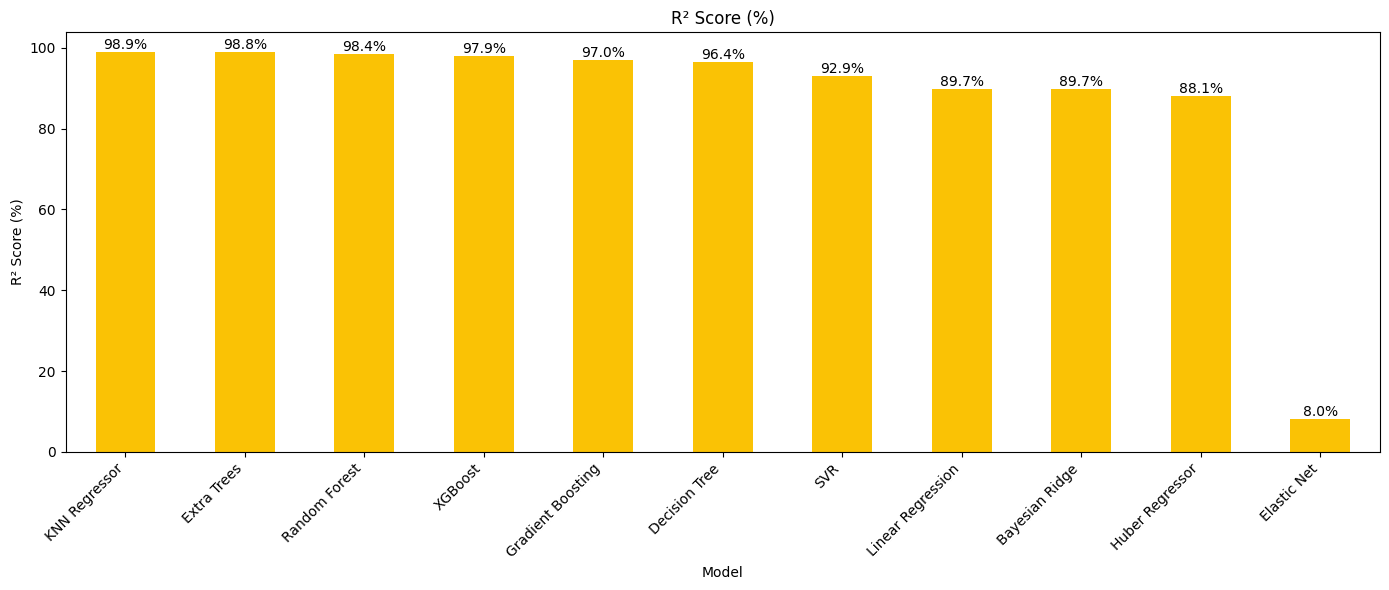

In [44]:
results_plot = results.copy()
results_plot['R² Score'] *= 100

ax = results_plot.plot(x='Model', y='R² Score', kind='bar', figsize=(14, 6),
                       legend=False, title='R² Score (%)', color='#FAC205')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

plt.xlabel('Model')
plt.ylabel('R² Score (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## HyperParameter Tuning

In [45]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(start = 1, stop = 500, num = 500)]
criterion = ['squared_error', 'absolute_error']
max_depth = [int(x) for x in np.linspace(10, 200, num = 100)]
min_samples_split = [2, 5, 10, 20]
min_samples_leaf = [1, 2, 4, 8]
max_features = [None, 'sqrt', 'log2']
max_leaf_nodes = [int(x) for x in np.linspace(10, 200, num = 100)]
max_depth.append(None)

random_grid = {'n_estimators': n_estimators,
               'criterion':criterion,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'max_leaf_nodes':max_leaf_nodes}


et = ExtraTreesRegressor()
et_random = RandomizedSearchCV(estimator = et, param_distributions = random_grid, n_iter = 200, cv = 3, verbose=0, random_state=42, n_jobs = -1)
et_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=ExtraTreesRegressor(), n_iter=200, n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error'],
                                        'max_depth': [10, 11, 13, 15, 17, 19,
                                                      21, 23, 25, 27, 29, 31,
                                                      33, 34, 36, 38, 40, 42,
                                                      44, 46, 48, 50, 52, 54,
                                                      56, 57, 59, 61, 63, 65, ...],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': [10, 11, 13, 15, 17,
                                                           19, 21, 23, 25, 27,
                                                           29, 31, 33, 34, 36,
                                                           38, 40, 42, 44, 46,
                                                           48, 50, 52, 54, 56,
                                                           57, 59, 61, 63, 65, ...],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8,
                                                         9, 10, 11, 12, 13, 14,
                                                         15, 16, 17, 18, 19, 20,
                                                         21, 22, 23, 24, 25, 26,
                                                         27, 28, 29, 30, ...]},
                   random_state=42)

In [46]:
et_tuned = ExtraTreesRegressor(**et_random.best_params_)
et_tuned.fit(X_train_scaled,y_train)

y_pred_et = et_tuned.predict(X_test_scaled)
r2ett = metrics.r2_score(y_test, y_pred_et)

print("-"*30)
print("Accuracy: ", r2ett)
print("-"*30)

------------------------------
Accuracy:  0.9856341992002003
------------------------------


(array([0, 1]),
 [Text(0, 0, 'Baseline Model'),
  Text(1, 0, 'Model after hyperparameter tuning')])

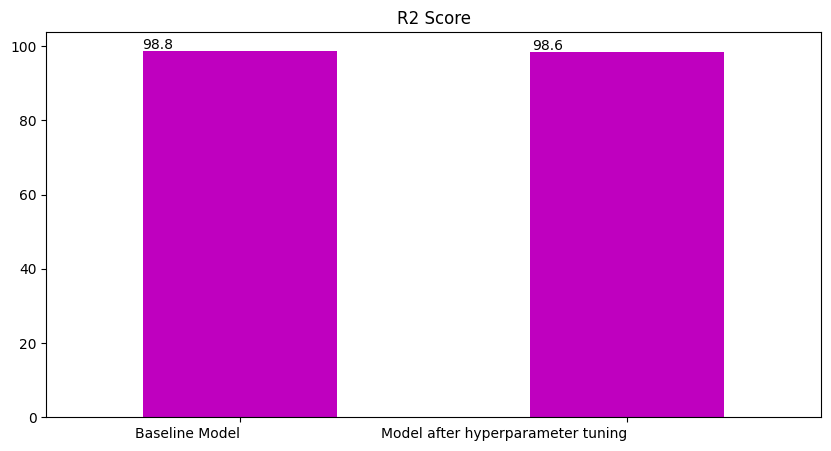

In [47]:
conclusion = {
    "R2 score": {
    "Baseline Model": results.loc[results["Model"] == "Extra Trees", "R² Score"].iloc[0] * 100,
    "Model after hyperparameter tuning": r2ett*100
    }
}

ax = pd.DataFrame(conclusion).plot(kind="bar", figsize = (10,5), legend =False, title = "R2 Score", color = 'm');
                    
for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 1)), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xticks(rotation=360, ha='right')

|                              |        Original | Reduced |
| ---------------------------- | --------------: | ------: |
| Total parameter combinations | **484,800,000** | **648** |
| `n_iter`                     |             200 |      30 |
| CV folds                     |               3 |       5 |
| Actual model fits            |         **600** | **150** |


In [48]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor

random_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['squared_error', 'absolute_error']
}

et = ExtraTreesRegressor(random_state=42)
et_random = RandomizedSearchCV(estimator=et, param_distributions=random_grid, n_iter=30, cv=5, scoring='r2', random_state=42, n_jobs=-1)
et_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=ExtraTreesRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error'],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [49]:
et_tuned = ExtraTreesRegressor(**et_random.best_params_)
et_tuned.fit(X_train_scaled,y_train)

y_pred_et = et_tuned.predict(X_test_scaled)
r2ett = metrics.r2_score(y_test, y_pred_et)

print("-"*30)
print("Accuracy: ", r2ett)
print("-"*30)

------------------------------
Accuracy:  0.9890140017790652
------------------------------


(array([0, 1]),
 [Text(0, 0, 'Baseline Model'),
  Text(1, 0, 'Model after hyperparameter tuning')])

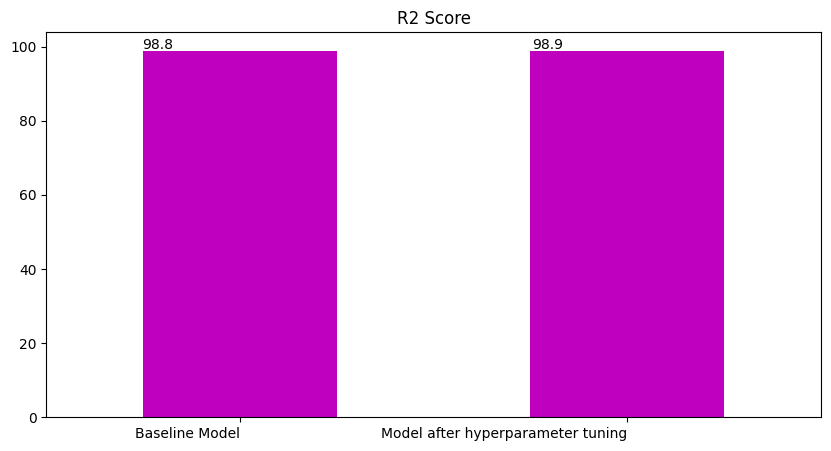

In [50]:
conclusion = {
    "R2 score": {
    "Baseline Model": results.loc[results["Model"] == "Extra Trees", "R² Score"].iloc[0] * 100,
    "Model after hyperparameter tuning": r2ett*100
    }
}

ax = pd.DataFrame(conclusion).plot(kind="bar", figsize = (10,5), legend =False, title = "R2 Score", color = 'm');
                    
for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 1)), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xticks(rotation=360, ha='right')
